In [1]:
# import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
import pandas as pd

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
runs = [500, 1000, 1_000_0, 1_000_00]#, 1_000_000]

I_0 = 10000
b_I = 8
tau_I = 10
d_IE = 3.8*10**(-4)
T_I = 2

infection_type = "prim" #"sec"

MI_args = np.hstack(([1],np.arange(10,len(stat_names))))

MI_b_I = np.zeros((len(runs),len(MI_args)))
MI_tau_I = np.zeros((len(runs),len(MI_args)))

### (1) Compute mutual information as a function of dataset size

In [3]:
# Parallelize simulation runs
sim_type = "pop_ode"

def for_parallel(I_params,
                 rate_cv = [0.5, 0.5, 0.5, 2.0],
                 sim_kind = sim_type):
    
    return sum_sim(b_I = I_params[0], tau_I = I_params[1], 
                   rate_cv = rate_cv, infection = infection_type, sim_kind = sim_kind)

In [4]:
run_count = 0

for run in runs:
    # run several simulations varying b_I,tau_I indep, logNorm()
    cv_b_I, cv_tau_I = 0.5, 0.5

    Is = np.random.lognormal(mean = np.log(np.array([b_I, tau_I])/np.sqrt(1 + np.array([cv_b_I, cv_tau_I])**2)), 
                                sigma = np.sqrt(np.log(1 + np.array([cv_b_I, cv_tau_I])**2)), size = (run,2))

    run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(len(Is)/8),1))(delayed(for_parallel)(I_params = I_params)
                                                  for I_params in Is), dtype=object)
    
    # Extract simulation results
    run_rates = np.zeros((run, len(run_data[:,0][0]) ))
    run_data_Is = np.zeros((run, len(run_data[:,1][0]) ))
    
    for i in np.arange(0,run):
        run_rates[i,:] = run_data[:,0][i]
        run_data_Is[i,:] = run_data[:,1][i]

    # compute mutual information
    for i, index in enumerate(np.hstack(([7],np.arange(10,len(stat_names))))):
        MI_b_I[run_count, i] = calc_MI(run_data_Is[:,7],run_data_Is[:,index])

    for i, index in enumerate(np.hstack(([8],np.arange(10,len(stat_names))))):
        MI_tau_I[run_count, i] = calc_MI(run_data_Is[:,8],run_data_Is[:,index])
    
    run_count += 1

In [5]:
#np.save('compute-MI.npy',run_data_b_a1)
run_data_Is.shape

(100000, 18)

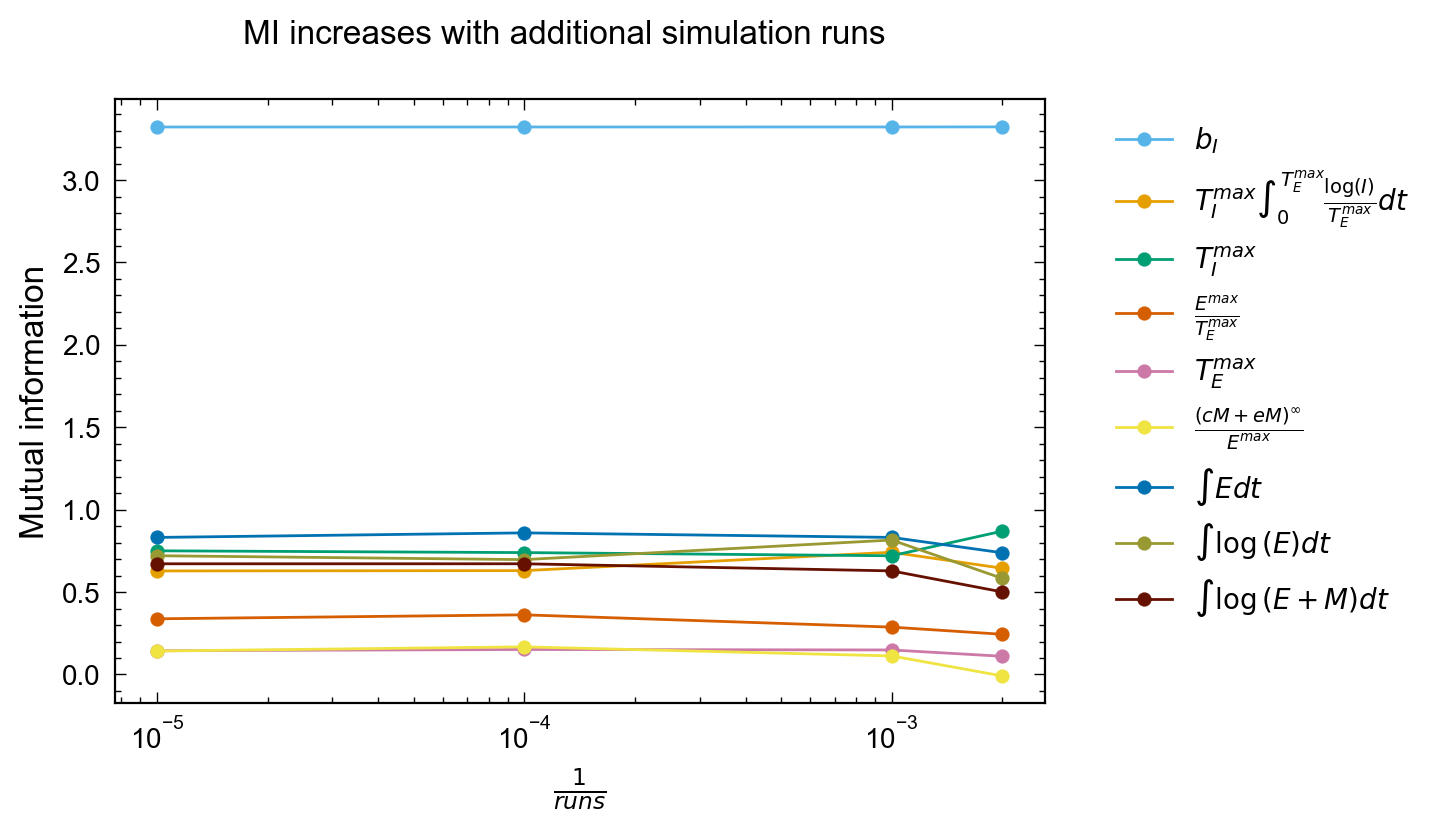

In [75]:
plt.plot(np.ones(len(runs))/runs, MI_b_I, 'o-', label = np.concatenate(([stat_names[7]],stat_names[10:]), axis = None))
plt.xlabel(r"$\frac{1}{runs}$")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('MI increases with additional simulation runs')
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'MI-scales-with-runs.png', dpi=150, bbox_inches="tight")

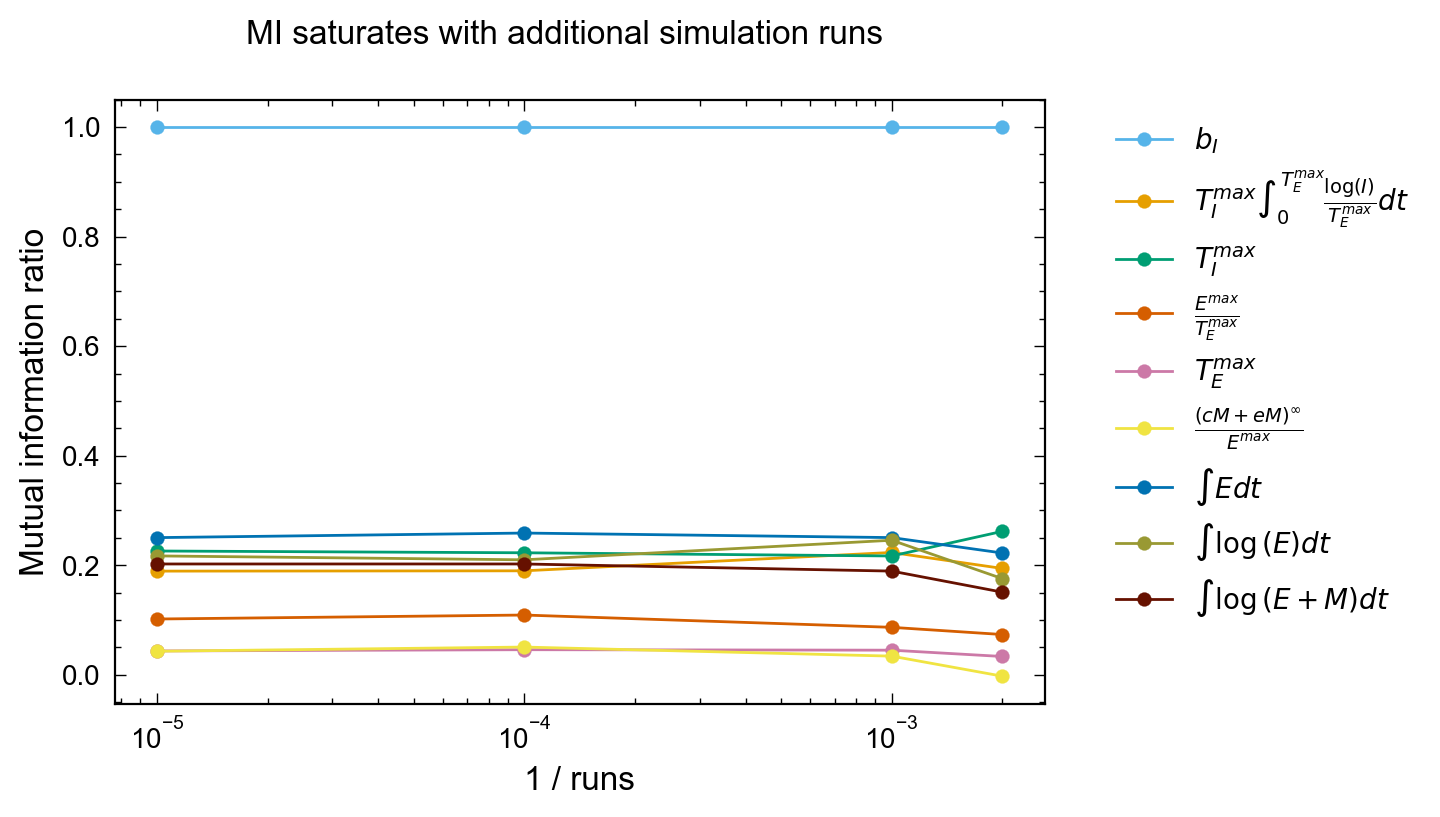

In [74]:
MI_b_I_frac = np.zeros(MI_b_I.shape)
for i in np.arange(len(runs)):
    MI_b_I_frac[i,:] = MI_b_I[i,:]/MI_b_I[i,0]
 

plt.plot(np.ones(len(runs))/runs, MI_b_I_frac, 'o-',label = np.concatenate(([stat_names[7]],stat_names[10:]), axis = None))
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.xlabel("1 / runs")
plt.suptitle('MI saturates with additional simulation runs')
plt.ylabel("Mutual information ratio")
plt.semilogx()
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'MI-stabilizes-with-runs.png', dpi=150, bbox_inches="tight")

### (2) Compute mutual information as a function of bin number

In [26]:
bin_nums = [5, 10, 25, 50, 100, 200, 300, 400, 500]
MI_b_I_bins = np.zeros((len(bin_nums),len(np.hstack(([7],np.arange(10,len(stat_names))))) ))
run_count = 0
#run_data_b_I = np.load('compute-MI.npy')

for bin_num in bin_nums:

    for i, index in enumerate(np.hstack(([7],np.arange(10,len(stat_names))))):
        MI_b_I_bins[run_count, i] = calc_MI(run_data_Is[:,7],run_data_Is[:, index], 
                                             bin_num,
                                            correction = False)
    run_count += 1

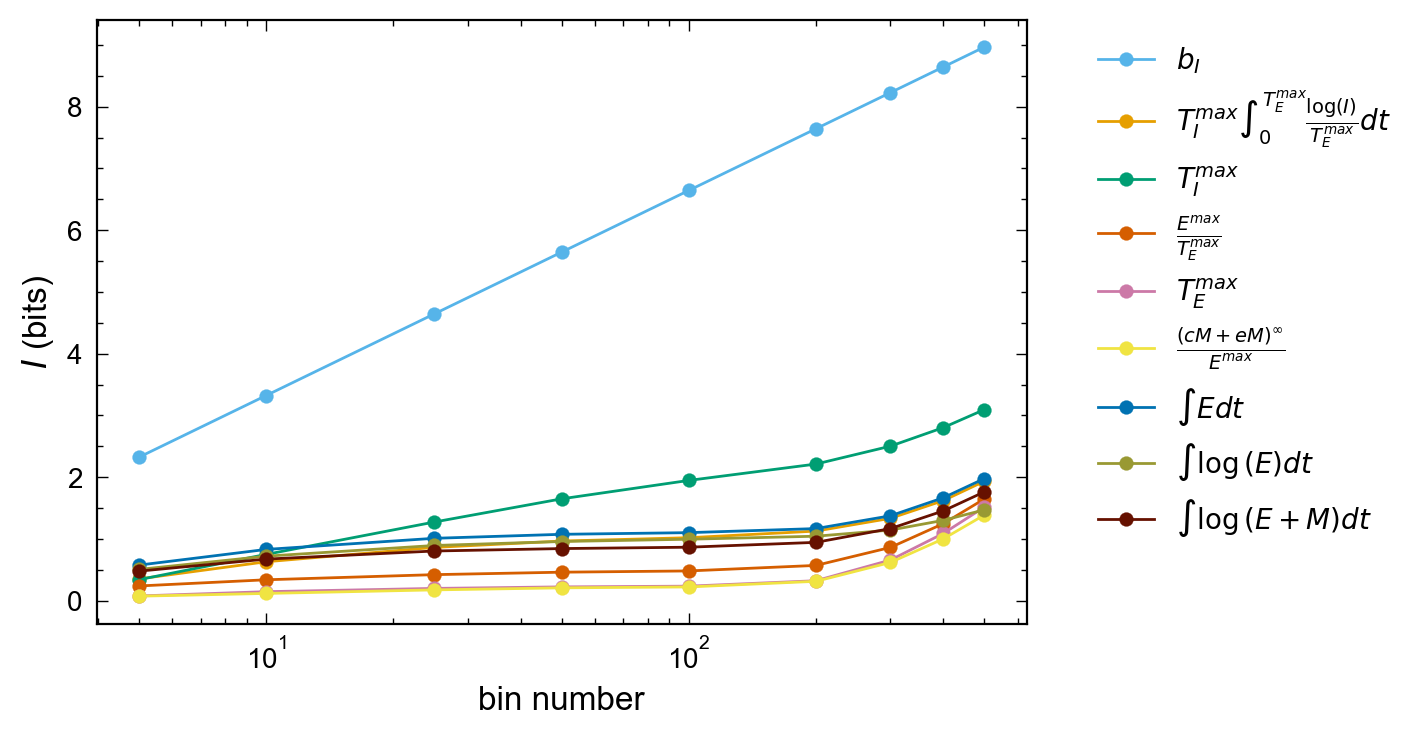

In [73]:
plt.plot(bin_nums, MI_b_I_bins, 'o-', label = np.concatenate(([stat_names[7]],stat_names[10:]), axis = None))
plt.xlabel("bin number")
plt.ylabel(r"$I$ (bits)")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle('Easy to under- or over-estimate MI')
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'MI-varies-with-bin-nums.png', dpi=150, bbox_inches="tight")

In [28]:
bin_nums = [5, 10, 25, 50, 100, 200, 300, 400, 500]
MI_b_I_error = np.zeros((len(bin_nums),len(np.hstack(([7],np.arange(10,len(stat_names))))) ))
run_count = 0
#run_data_b_a1 = np.load('compute-MI.npy')

for bin_num in bin_nums:

    for i, index in enumerate(np.hstack(([7],np.arange(10,len(stat_names))))):
        MI_b_I_error[run_count, i] = calc_MI(run_data_Is[:,7],
                                             (run_data_Is[:,index])[np.random.permutation((run_data_Is[:,index]).shape[0])], 
                                             bin_num,
                                            correction = False)
    run_count += 1

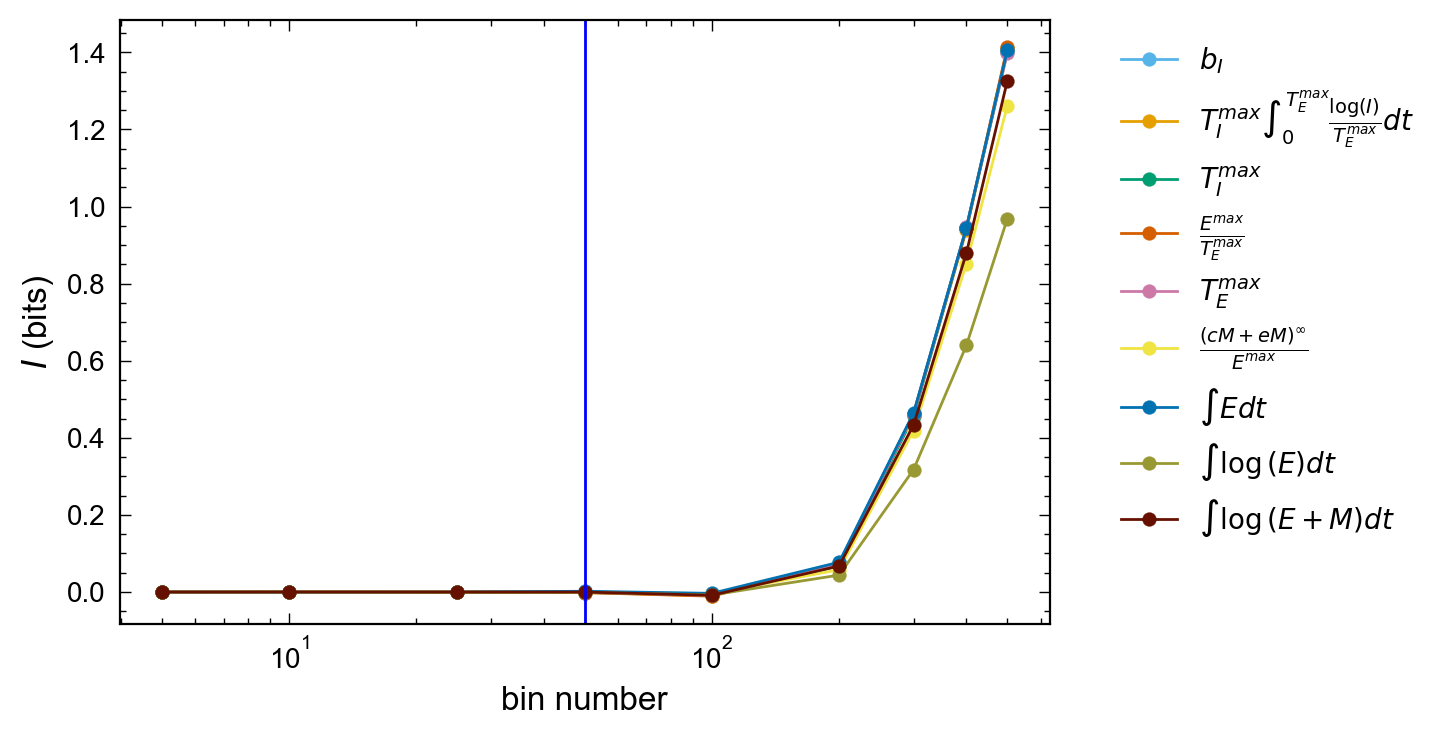

In [71]:
plt.plot(bin_nums, MI_b_I_error, 'o-', label = np.concatenate(([stat_names[7]],stat_names[10:]), axis = None))
plt.axvline(x = 50, color = 'b')
plt.xlabel("bin number")
plt.ylabel(r"$I$ (bits)")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle('There is an optimal bin size for MI')
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'error-MI-varies-with-bin-nums.png', dpi=150, bbox_inches="tight")

### (3) Example of extrapolation procedure to compute mutual information as a function of bin number

In [36]:
from sklearn.metrics import mutual_info_score
from sklearn.linear_model import LinearRegression

x, y = run_data_Is[:,7],run_data_Is[:, 16]
subsample_size = np.array([0.6, 0.7, 0.8, 0.9, 0.95, 1.0])*x.size
replicates = 20

mi_data = np.zeros((subsample_size.size*replicates, 2))
entry = 0
correction = False
bin_num = 50

for sub in subsample_size:
    for i in np.arange(0,replicates):
        choice =  np.random.choice(int(sub), int(sub))
        x_, y_ = x[choice], y[choice]


        _, bx = pd.qcut(x_, bin_num, retbins=True, duplicates = 'drop')
        _, by = pd.qcut(y_, bin_num, retbins=True, duplicates = 'drop')

        if bx.size == 1:
            bx = np.append(bx, bx +1)

        if by.size == 1:
            by = np.append(by, by +1)

        c_xy = np.histogram2d(x_, y_, (bx,by))[0]
        mi_raw = mutual_info_score(None, None, contingency=c_xy)/np.log(2)

        # MI correction by shuffling data
        c_xy_shuffle = np.histogram2d(x_, y_[np.random.permutation(y_.shape[0])], (bx,by))[0]
        mi_correction = mutual_info_score(None, None, contingency=c_xy_shuffle)/np.log(2)

        if correction == True:
            out = mi_raw - mi_correction
        else:
            out = mi_raw

        mi_data[entry, 1], mi_data[entry, 0] = out, 1/sub

        entry += 1

lr = LinearRegression()
lr.fit(mi_data[:,0].reshape(-1,1), mi_data[:,1].reshape(-1,1))

LinearRegression()

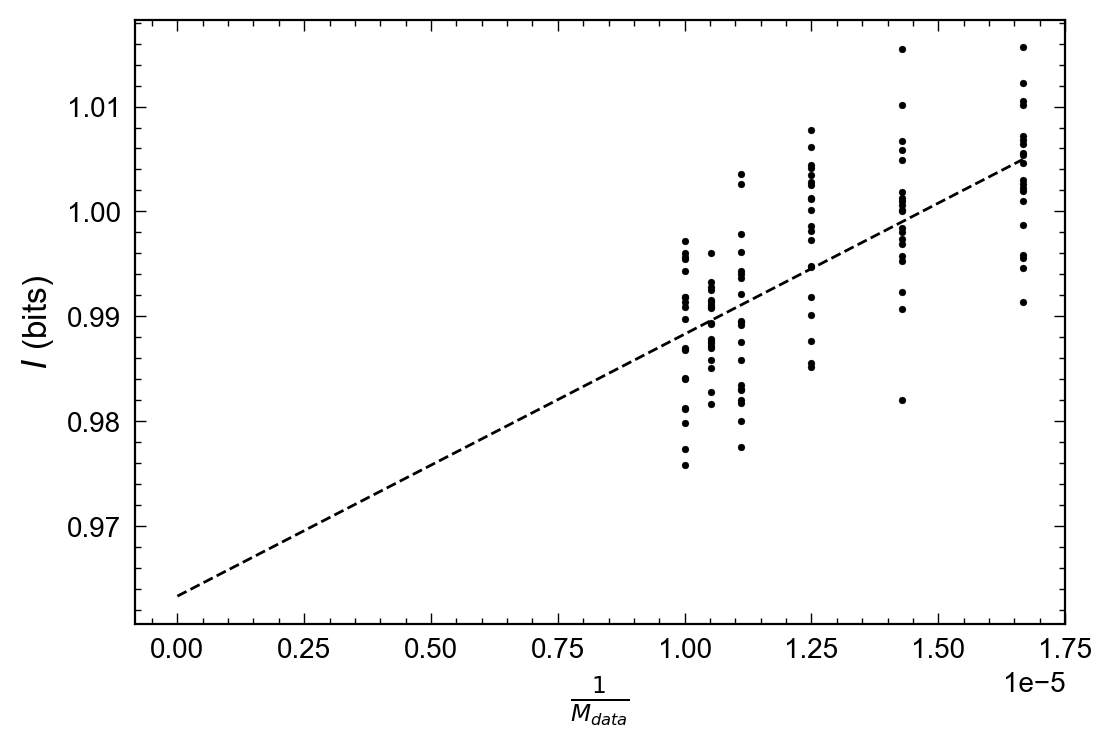

In [72]:
plt.plot(np.unique(np.hstack(([0.0],mi_data[:,0]))), lr.predict(np.unique(np.hstack(([0.0],mi_data[:,0]))).reshape(-1,1)), 'k--')
plt.plot(mi_data[:,0], mi_data[:,1], 'k.')#, label = stat_names[16])
plt.xlabel(r"$\frac{1}{M_{data}}$")
plt.ylabel(r"$I$ (bits)")
#plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle('There is an optimal bin size for MI')
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'extrapolating-MI.png', dpi=150, bbox_inches="tight")